# Regression with a Perceptron

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture introducing the **perceptron**
(Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- what a **perceptron** is — the fundamental unit of a neural network
- how **linear regression** is exactly a single perceptron
- the house-price motivation (size, then size + rooms, then many features)
- the model $\hat{y} = w_1 x_1 + w_2 x_2 + b$ (no activation) and its vector form
- the goal: find the weights and bias that minimize the prediction **error**
- a Python implementation, a fitted line, and a perceptron diagram

This notebook follows the repository `GUIDELINES.md` template and begins the
neural-networks part of the course, building on *Gradient Descent* and *Least Squares*.

## 1. Introduction

> *"Welcome to Week 3. You're going to learn what a neural network is and how to train it
> using gradient descent... The fundamental unit of neural networks is called a
> perceptron. You've actually seen one already, because linear regression can be expressed
> as a perceptron."*

A **perceptron** takes some inputs, combines them with **weights** and a **bias**, and
produces an output. When there is no activation function, that output is exactly a linear
regression prediction.

After this notebook you will be able to:

- describe the perceptron's inputs, weights, bias, and output
- write the model both component-wise and in vector form
- see why linear regression *is* a one-perceptron model
- state what "training" means (minimizing a loss — covered next)

## 2. Motivation: predicting house prices

We want to predict a house's **price** from its **size**. Three example houses:

| size (sq ft) | price |
|---|---|
| 1000 | \$20,000 |
| 2000 | \$30,000 |
| 3000 | \$50,000 |

With more houses plotted, the points roughly form a **line**, so we look for the best line
to predict price from size.

best line: price ≈ 15.00 * size + 3333.3


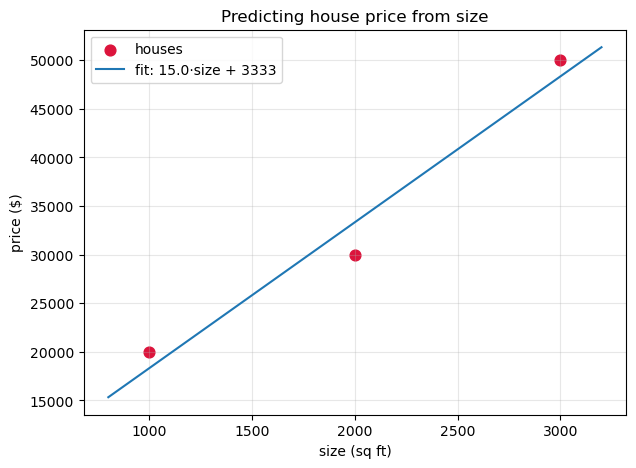

In [1]:
import numpy as np
import matplotlib.pyplot as plt

size  = np.array([1000, 2000, 3000], dtype=float)
price = np.array([20000, 30000, 50000], dtype=float)

# best-fit line (single feature) via least squares
w, b = np.polyfit(size, price, 1)
print(f"best line: price ≈ {w:.2f} * size + {b:.1f}")

xs = np.linspace(800, 3200, 100)
plt.figure(figsize=(7, 5))
plt.scatter(size, price, s=60, color="crimson", label="houses")
plt.plot(xs, w*xs + b, label=f"fit: {w:.1f}·size + {b:.0f}")
plt.title("Predicting house price from size")
plt.xlabel("size (sq ft)"); plt.ylabel("price ($)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

### Adding more features

> *"What if we threw in a second feature — the number of rooms?"*

Now each house has two inputs: size $x_1$ and number of rooms $x_2$ (e.g. 2, 4, 7 rooms).
The problem is no longer a simple 2D line — we must account for **both** features. And we
might have 10 or 100 features. This is where the **perceptron** comes in: it handles any
number of inputs uniformly.

## 3. The perceptron, mathematically

The perceptron takes inputs $x_1, x_2, \dots$ (imagine up to $x_{100}$), feeds them into a
**summation function**, and outputs a prediction $\hat{y}$.

Inside the summation:

- each input $x_i$ is multiplied by a **weight** $w_i$ that says how important it is,
- the weighted inputs are added,
- a **bias** $b$ is added.

> *"If the size of a house is way more important than the number of rooms, then it will
> have a higher weight."*

With two features and **no activation function**:

$$
\hat{y} = w_1 x_1 + w_2 x_2 + b .
$$

For $n$ features this is the dot product

$$
\hat{y} = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}\cdot\mathbf{x} + b .
$$

This is precisely the **linear regression** prediction — so linear regression is a single
perceptron.

In [2]:
def perceptron(x, w, b):
    # Forward pass of a perceptron with no activation: y_hat = w·x + b
    return np.dot(w, x) + b

# Example: a house with size 2000 sq ft and 4 rooms
x = np.array([2000, 4])         # features: [size, rooms]
w = np.array([14.0, 1500.0])    # example weights (importance of each feature)
b = 2000.0                      # example bias

y_hat = perceptron(x, w, b)
print(f"inputs x = {x}")
print(f"weights w = {w}, bias b = {b}")
print(f"prediction  y_hat = w1·x1 + w2·x2 + b = {y_hat:.1f}")

inputs x = [2000    4]
weights w = [  14. 1500.], bias b = 2000.0
prediction  y_hat = w1·x1 + w2·x2 + b = 36000.0


## 4. A picture of the perceptron

Inputs flow in, get weighted and summed with the bias, and produce the output $\hat{y}$.

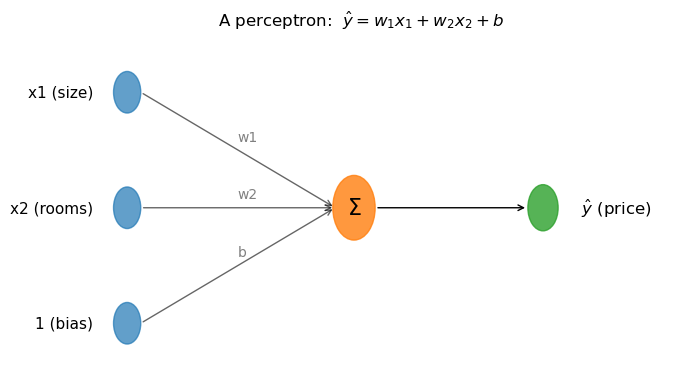

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# input nodes
inputs = ["x1 (size)", "x2 (rooms)", "1 (bias)"]
ys = [3, 2, 1]
for label, yy in zip(inputs, ys):
    ax.add_patch(plt.Circle((1, yy), 0.18, color="tab:blue", alpha=0.7))
    ax.text(0.55, yy, label, ha="right", va="center", fontsize=11)

# summation node
ax.add_patch(plt.Circle((4, 2), 0.28, color="tab:orange", alpha=0.8))
ax.text(4, 2, r"$\Sigma$", ha="center", va="center", fontsize=16)

# output node
ax.add_patch(plt.Circle((6.5, 2), 0.2, color="tab:green", alpha=0.8))
ax.text(7.0, 2, r"$\hat{y}$ (price)", ha="left", va="center", fontsize=12)

# edges with weight labels
for yy, wlabel in zip(ys, ["w1", "w2", "b"]):
    ax.annotate("", xy=(3.75, 2), xytext=(1.18, yy),
                arrowprops=dict(arrowstyle="->", alpha=0.6))
    ax.text((1.18 + 3.75)/2, (yy + 2)/2 + 0.08, wlabel, fontsize=10, color="gray")
ax.annotate("", xy=(6.3, 2), xytext=(4.28, 2), arrowprops=dict(arrowstyle="->"))

ax.set_xlim(0, 8.2); ax.set_ylim(0.5, 3.5)
ax.axis("off")
ax.set_title(r"A perceptron:  $\hat{y} = w_1 x_1 + w_2 x_2 + b$")
plt.show()

## 5. Training: minimizing the error

> *"The goal is to find the best $w_1, w_2$ and $b$ — the weights and bias that optimize
> predictions... We want to minimize some kind of error: how far are you from the actual
> price? For that we introduce the loss function."*

"Training" the perceptron means choosing $\mathbf{w}$ and $b$ so the predictions $\hat{y}$
are as close as possible to the true prices. We measure "how far off" with a **loss
function** (the squared error, as in least squares), then minimize it with **gradient
descent** — the subject of the next videos.

A quick look at how wrong some example weights are on our single-feature data:

In [4]:
def squared_error(w, b, x, y):
    preds = w * x + b
    return np.mean((preds - y)**2)

# compare a poor guess to the least-squares fit from section 2
w_fit, b_fit = np.polyfit(size, price, 1)
print(f"poor guess  (w=5,  b=0):     loss = {squared_error(5, 0, size, price):,.0f}")
print(f"best fit    (w={w_fit:.1f}, b={b_fit:.0f}): loss = {squared_error(w_fit, b_fit, size, price):,.0f}")

poor guess  (w=5,  b=0):     loss = 616,666,667
best fit    (w=15.0, b=3333): loss = 5,555,556


## 6. Exercises

### Basic
1. Write the perceptron output for two features $x_1, x_2$ with weights $w_1, w_2$ and bias
   $b$.
2. What role does each weight $w_i$ play?

### Intermediate
3. Compute the perceptron prediction for a house with size $2500$ and $5$ rooms using
   $w = (14, 1500)$ and $b = 2000$.
4. Using the single-feature fit $price = w\cdot size + b$ from section 2, predict the price
   of a $2500$ sq ft house.

### Advanced
5. Write the perceptron prediction in vector form for $n$ features, and implement it for a
   house with 4 features and arbitrary weights.
6. Explain why a perceptron *without* an activation function is exactly linear regression.

## 7. Solutions / Checks

In [5]:
# 3.
print("3.", perceptron(np.array([2500, 5]), np.array([14.0, 1500.0]), 2000.0))

# 4.
print(f"4. price(2500) = {w_fit*2500 + b_fit:,.0f}")

# 5. n-feature perceptron
x4 = np.array([2500, 5, 2, 1990])     # size, rooms, baths, year
w4 = np.array([12.0, 1500.0, 3000.0, 10.0])
print("5. y_hat =", perceptron(x4, w4, 500.0))

print("6. With no activation, y_hat = w·x + b is a linear function of the inputs — "
      "the exact form of a linear-regression model.")

3. 44500.0
4. price(2500) = 40,833
5. y_hat = 63900.0
6. With no activation, y_hat = w·x + b is a linear function of the inputs — the exact form of a linear-regression model.


## 8. Conclusion

- A **perceptron** is the fundamental unit of a neural network: weighted inputs plus a
  bias produce an output.
- With no activation function its output is $\hat{y} = \mathbf{w}\cdot\mathbf{x} + b$ —
  exactly **linear regression**.
- It scales effortlessly from 1 feature (house size) to many (rooms, baths, year, …).
- **Training** means finding the weights and bias that minimize the prediction error,
  measured by a **loss function** and minimized with **gradient descent** — the next
  topics, which lead toward full neural networks.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_1.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture introducing the **perceptron**. Key spoken points, lightly
cleaned:

> Week 3: learn what a neural network is, how to train it with gradient descent, and an
> alternative called Newton's method. The fundamental unit is the perceptron, and linear
> regression can be expressed as one. Motivation: predict a house's price from its size —
> e.g. 1000 sq ft → \$20k, 2000 → \$30k, 3000 → \$50k — the points form a line, and we
> want the best line. Add a second feature (rooms: 2, 4, 7) and it's no longer simple;
> with 10 or 100 features the perceptron handles it. The perceptron takes inputs
> $x_1,\dots,x_n$ into a summation function and outputs $\hat{y}$. Each input is multiplied
> by a weight (its importance), the products are summed, and a bias is added; with no
> activation function the output is $\hat{y} = w_1 x_1 + w_2 x_2 + b$ — the predicted
> price. The goal is the best $w_1, w_2, b$, found by minimizing the error via a loss
> function (next video).